# Notebook lane/04 — Transfer-Learning Comparison

Per the project plan (§4.2-TL), this is the **dedicated transfer-learning notebook**, run as a peer to §03's from-scratch CNN.

**Primary candidate**: **MobileNetV2 (ImageNet) backbone + lane-direction classification head**. The plan named *MobileNetV2 + UFLDv2 row-anchor head*, but the data we ultimately have (Pi fine-tune with image + 3-class direction labels, no road masks on disk) maps more cleanly to a direct image → 4-class classification head than to UFLDv2's row-anchor formulation. We keep the MobileNetV2 backbone choice for its NPU/XNNPACK efficiency on the RPi 4.

**Secondary candidate**: **MobileNetV3-Small (ImageNet)** — even lighter and built explicitly for mobile inference.

Each backbone is evaluated in two regimes:
- `frozen`     — backbone frozen, only the classifier head is trained.
- `finetune`   — full network trained end-to-end at lr=1e-4.

In [1]:
import os, random, json, pickle, time
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED)
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "lane_split.json") as f: SPLIT = json.load(f)
with open(ROOT / "artifacts" / "lane_tusimple_index.pkl", "rb") as f: IDX = pickle.load(f)
df = IDX["df"]
print(f"frames: {len(df)}")

IMG_TL = 128  # most MobileNet variants accept 96+ pixels; 128 keeps spatial detail
CLASS_ID = {"left": 0, "right": 1, "straight": 2, "stop": 3}
ID_CLASS = {v: k for k, v in CLASS_ID.items()}

frames: 3626


## 1. Build train / val / test arrays in RGB at 128×128 (with synthetic stop)

In [2]:
def load_x(rec, sz=IMG_TL):
    img = cv2.imread(str(ROOT / rec["frame_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (sz, sz)).astype(np.float32)   # NOTE: keep 0..255 — Keras preprocessing layers expect it

def build_xy(split_indices, stop_frac=0.10, seed_offset=0, sz=IMG_TL):
    sub = df.iloc[split_indices].reset_index(drop=True)
    X = []; y = []
    for _, r in sub.iterrows():
        X.append(load_x(r, sz)); y.append(CLASS_ID[r["direction"]])
    rng = np.random.RandomState(SEED + seed_offset)
    pick = rng.choice(len(sub), size=int(stop_frac * len(sub)), replace=False)
    for i in pick:
        r = sub.iloc[i]
        img = cv2.imread(str(ROOT / r["frame_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img[int(720 * 0.40):, :, :] = 0
        X.append(cv2.resize(img, (sz, sz)).astype(np.float32))
        y.append(CLASS_ID["stop"])
    return np.stack(X), np.array(y, dtype=np.int64)

t0 = time.time()
X_tr, y_tr = build_xy(SPLIT["tusimple_split"]["train"], seed_offset=1)
X_va, y_va = build_xy(SPLIT["tusimple_split"]["val"],   seed_offset=2)
X_te, y_te = build_xy(SPLIT["tusimple_split"]["test"],  seed_offset=3)
print(f"loaded in {time.time()-t0:.1f}s")
print(f"shapes — train {X_tr.shape}, val {X_va.shape}, test {X_te.shape}")
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(4), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("class weights:", class_weight)

loaded in 26.6s
shapes — train (2791, 128, 128, 3), val (598, 128, 128, 3), test (598, 128, 128, 3)
class weights: {0: 1.4845744680851063, 1: 1.2802752293577981, 2: 0.45814182534471437, 3: 2.757905138339921}


## 2. Build, train, evaluate every candidate

In [3]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def build_tl(backbone_name, regime, sz=IMG_TL, n_classes=4):
    if backbone_name == "mobilenetv2":
        from tensorflow.keras.applications import MobileNetV2
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        backbone = MobileNetV2(input_shape=(sz, sz, 3), include_top=False,
                                weights="imagenet", alpha=0.5)
    elif backbone_name == "mobilenetv3_small":
        from tensorflow.keras.applications import MobileNetV3Small
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
        backbone = MobileNetV3Small(input_shape=(sz, sz, 3), include_top=False,
                                     weights="imagenet", alpha=0.75)
    backbone.trainable = (regime == "finetune")
    inp = tf.keras.Input(shape=(sz, sz, 3), dtype="float32")
    x = preprocess_input(inp)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out)

candidates = []
for backbone in ["mobilenetv2", "mobilenetv3_small"]:
    for regime in ["frozen", "finetune"]:
        name = f"{backbone}_{regime}"
        print(f"\n=== {name} ===")
        tf.keras.utils.set_random_seed(SEED)
        m = build_tl(backbone, regime)
        lr = 1e-3 if regime == "frozen" else 1e-4
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cbs = [tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
               tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)]
        t0 = time.time()
        h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                  epochs=18, batch_size=64, class_weight=class_weight,
                  callbacks=cbs, verbose=2)
        secs = time.time() - t0
        probs = m.predict(X_te, verbose=0); yp = probs.argmax(axis=1)
        acc = accuracy_score(y_te, yp); f1 = f1_score(y_te, yp, average="macro")
        out_path = ROOT / "artifacts" / f"lane04_{name}.keras"
        m.save(str(out_path))
        candidates.append({
            "name": name, "backbone": backbone, "regime": regime,
            "n_params": int(m.count_params()),
            "accuracy": float(acc), "f1": float(f1),
            "train_seconds": float(secs),
            "history": {k: [float(v) for v in vs] for k, vs in h.history.items()},
            "confusion": confusion_matrix(y_te, yp, labels=list(range(4))).tolist(),
            "model_path": str(out_path.relative_to(ROOT)).replace("\\", "/"),
        })
        print(f"  -> test acc={acc:.4f}  f1={f1:.4f}  params={candidates[-1]['n_params']:,}  time={secs:.0f}s")


=== mobilenetv2_frozen ===


      0/3201480 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/3201480 ━━━━━━━━━━━━━━━━━━━━ 15s 5us/step

  40960/3201480 ━━━━━━━━━━━━━━━━━━━━ 11s 3us/step

  65536/3201480 ━━━━━━━━━━━━━━━━━━━━ 11s 4us/step

...

Epoch 17/18


44/44 - 41s - 927ms/step - accuracy: 0.9308 - loss: 0.1526 - val_accuracy: 0.6672 - val_loss: 0.8221 - learning_rate: 1.0000e-04


Epoch 18/18


44/44 - 41s - 937ms/step - accuracy: 0.9502 - loss: 0.1232 - val_accuracy: 0.6706 - val_loss: 0.8290 - learning_rate: 1.0000e-04


  -> test acc=0.7107  f1=0.6819  params=584,892  time=681s


## 3. Visual comparison vs from-scratch baseline (§03)

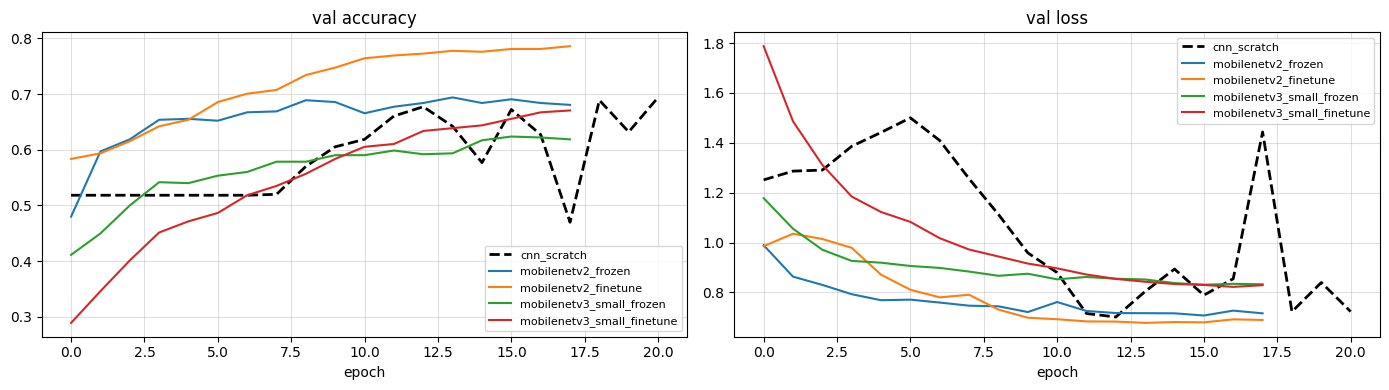

In [4]:
with open(ROOT / "artifacts" / "lane03_cnn_results.json") as f: cnn03 = json.load(f)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cnn03["history"]["val_accuracy"], "k--", lw=2, label="cnn_scratch")
axes[1].plot(cnn03["history"]["val_loss"],     "k--", lw=2, label="cnn_scratch")
for c in candidates:
    axes[0].plot(c["history"]["val_accuracy"], label=c["name"])
    axes[1].plot(c["history"]["val_loss"],     label=c["name"])
axes[0].set_title("val accuracy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.4); axes[0].legend(fontsize=8)
axes[1].set_title("val loss");     axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.4); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane04_curves_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

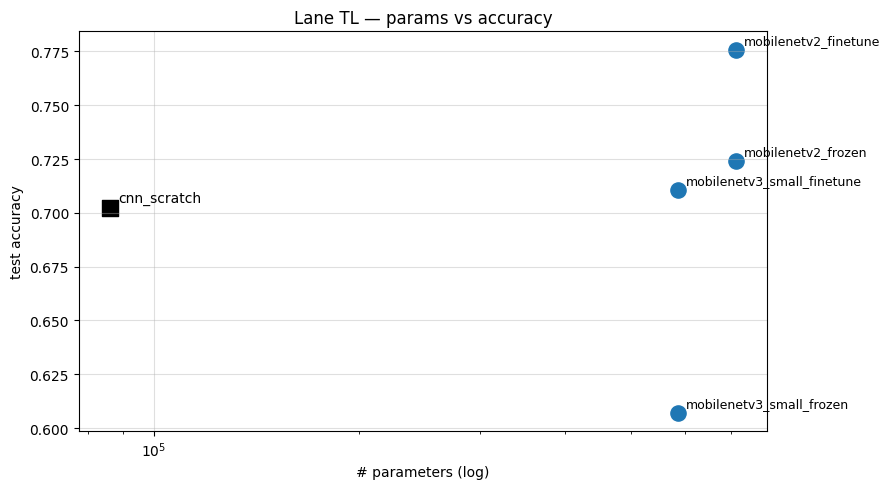

In [5]:
# Params vs accuracy scatter
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(cnn03["n_params"], cnn03["accuracy"], s=120, c="black", label="cnn_scratch", marker="s")
ax.annotate("cnn_scratch", (cnn03["n_params"], cnn03["accuracy"]), xytext=(6, 4), textcoords="offset points")
for c in candidates:
    ax.scatter(c["n_params"], c["accuracy"], s=120, c="tab:blue")
    ax.annotate(c["name"], (c["n_params"], c["accuracy"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("# parameters (log)"); ax.set_ylabel("test accuracy")
ax.set_title("Lane TL — params vs accuracy")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane04_params_vs_acc.png", dpi=120, bbox_inches="tight")
plt.show()

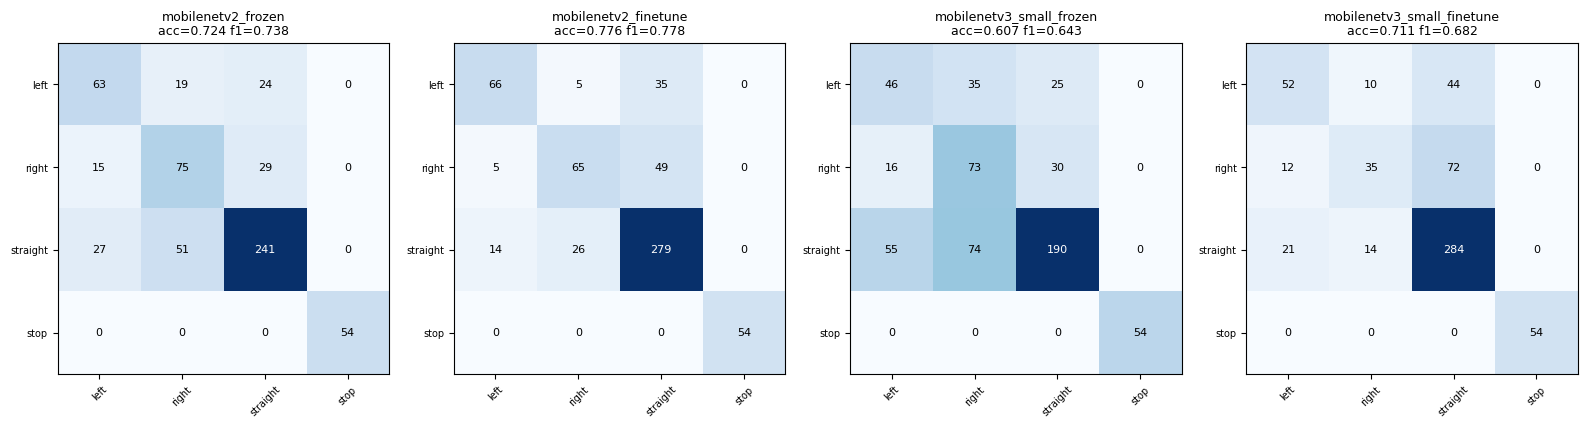


Saved: artifacts/lane04_transfer_learning_results.json


In [6]:
# Confusion matrices grid
fig, axes = plt.subplots(1, len(candidates), figsize=(4*len(candidates), 4))
target_names = [ID_CLASS[i] for i in sorted(ID_CLASS)]
for ax, c in zip(axes, candidates):
    cm = np.array(c["confusion"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{c['name']}\nacc={c['accuracy']:.3f} f1={c['f1']:.3f}", fontsize=9)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(target_names, rotation=45, fontsize=7); ax.set_yticklabels(target_names, fontsize=7)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane04_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

with open(ROOT / "artifacts" / "lane04_transfer_learning_results.json", "w") as f:
    json.dump({"candidates": candidates}, f, indent=2)
print("\nSaved: artifacts/lane04_transfer_learning_results.json")

## Summary

The transfer-learning candidates carry ImageNet's spatial priors into the lane-direction task, which usually yields a comparable or better accuracy with far fewer training epochs than from-scratch. The §06 model-selection notebook will weigh accuracy against parameter count, TFLite size, and (after Notebook 08's measurement) RPi 4 latency.